# Notebook 12: Error-Driven Augmentation

## Purpose
Evaluate classifier-specific error-driven augmentation — the most principled
augmentation strategy in this project. Unlike Notebooks 10-11 which used a
single shared synthetic pool, each classifier here receives augmentation
tailored to its own failure modes.

## Methodology
For each classifier (LR, MLP-1, MLP-2):
1. False positives on the training set were identified at the Notebook 09
   threshold (τ=0.69 for all three)
2. K-means clustering (k=200) applied to false positive embeddings —
   selects diverse, representative failure modes rather than redundant
   near-duplicate errors
3. Sentence closest to each centroid selected as generation seed
4. `Llama-3-8B-Instruct` (temperature=0.7) rewrites each seed as a
   genuine hedge — preserving topic and vocabulary but adding real
   epistemic uncertainty
5. Two variants generated per seed, each using a different hedging device
6. Filtered by cosine similarity to nearest real positive (τ=0.8) —
   same filter as Notebook 10

## Why Classifier-Specific?
Each model makes structurally different errors:
- LR: 5,083 false positives (7.3%) — over-predicts due to linear boundary
- MLP-1: 1,134 false positives (1.6%) — more selective, harder failure modes
- MLP-2: 1,473 false positives (2.1%) — intermediate error profile

Augmenting with a shared pool would mix error types across models.
Classifier-specific augmentation ensures each model is challenged on
its own blind spots.

## Generated Files
| Classifier | Seeds | Raw variants | Source |
|---|---|---|---|
| LR | 199 | 398 | `error_driven_lr_raw.parquet` |
| MLP-1 | 200 | ~400 | `error_driven_mlp1_raw.parquet` |
| MLP-2 | 200 | ~400 | `error_driven_mlp2_raw.parquet` |

## Filtering
Cosine similarity to nearest real positive at τ=0.8 — identical to
Notebook 10. Error-driven variants are genuine hedges (label=1) so
the same filter logic applies: retain candidates geometrically close
to the real positive manifold.

## Evaluation
- UMAP: one plot per classifier condition, filtered synthetics overlaid
- Metrics table: precision, recall, F1 vs Notebooks 09-11
- DET curves: all conditions overlaid
- Key question: does classifier-specific augmentation outperform the
  shared augmentation strategies from Notebooks 10-11?

In [1]:
# -----------------------------------------------
# Imports — identical to Notebooks 09-11
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
os.chdir("..")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -----------------------------------------------
# Imports — identical to Notebooks 09-11
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# -----------------------------------------------
# Paths — synthetic parquets per classifier
# These will be populated as generation completes:
#   LR:    already done
#   MLP-1: in progress
#   MLP-2: tomorrow
# -----------------------------------------------
SYNTHETIC_PATHS = {
    'LR':    "data/synthetic/error_driven_lr_raw.parquet",
    'MLP-1': "data/synthetic/error_driven_mlp1_raw.parquet",
    'MLP-2': "data/synthetic/error_driven_mlp2_raw.parquet",
}

# Real embeddings and splits
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# Load prior baseline metrics for comparison
with open("data/results/metrics_09_baseline.json") as f:
    baseline_09 = json.load(f)
with open("data/results/metrics_10_positive_aug.json") as f:
    baseline_10 = json.load(f)
with open("data/results/metrics_11_contrastive_aug.json") as f:
    baseline_11 = json.load(f)

print("\nPrior baselines loaded: Notebooks 09, 10, 11")

# -----------------------------------------------
# Verify which synthetic files are ready
# -----------------------------------------------
print("\nSynthetic file status:")
for clf_name, path in SYNTHETIC_PATHS.items():
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"  ✓ {clf_name}: {len(df)} variants — {path}")
    else:
        print(f"  ✗ {clf_name}: not yet generated — {path}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

Prior baselines loaded: Notebooks 09, 10, 11

Synthetic file status:
  ✓ LR: 398 variants — data/synthetic/error_driven_lr_raw.parquet
  ✓ MLP-1: 400 variants — data/synthetic/error_driven_mlp1_raw.parquet
  ✓ MLP-2: 400 variants — data/synthetic/error_driven_mlp2_raw.parquet


In [3]:
# -----------------------------------------------
# Utilities and model definitions
# Identical to Notebooks 09-11 — self-contained
# -----------------------------------------------
def optimal_threshold_f1(
    y_true, y_scores,
    thresholds=np.arange(0.01, 0.70, 0.01),
):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


class MLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dims=[256], dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class MLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, hidden_dims=[256], n_epochs=50, lr=1e-3,
        batch_size=256, patience=5, dropout=0.1, random_state=SEED,
    ):
        self.hidden_dims   = hidden_dims
        self.n_epochs      = n_epochs
        self.lr            = lr
        self.batch_size    = batch_size
        self.patience      = patience
        self.dropout       = dropout
        self.random_state  = random_state
        self.classes_      = np.array([0, 1])

    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)
        n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
        class_weights = torch.tensor(
            [1.0 / n_neg, 1.0 / n_pos], dtype=torch.float
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.model_ = MLP(X.shape[1], self.hidden_dims, self.dropout)
        optimizer = AdamW(
            self.model_.parameters(), lr=self.lr, weight_decay=1e-4
        )
        loader = DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float),
                torch.tensor(y, dtype=torch.long),
            ),
            batch_size=self.batch_size, shuffle=True,
        )
        best_cal_f1, best_weights, no_improve = 0.0, None, 0
        for epoch in range(self.n_epochs):
            self.model_.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()
            if X_cal is not None and y_cal is not None:
                _, cal_f1 = optimal_threshold_f1(
                    y_cal, self.predict_proba(X_cal)[:, 1]
                )
                if cal_f1 > best_cal_f1:
                    best_cal_f1 = cal_f1
                    best_weights = {
                        k: v.clone()
                        for k, v in self.model_.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best cal F1: {best_cal_f1:.4f})")
                        break
        if best_weights is not None:
            self.model_.load_state_dict(best_weights)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            probs = torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def evaluate_classifier(clf, X_train, y_train, X_cal, y_cal,
                         X_test, y_test, name="Classifier"):
    if isinstance(clf, MLPClassifier):
        clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
    else:
        clf.fit(X_train, y_train)
    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"\n=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))
    return {
        'name': name, 'clf': clf, 'threshold': t,
        'cal_f1': cal_f1, 'test_scores': test_scores,
        'y_pred': y_pred, 'precision': prec, 'recall': rec, 'f1': f1,
    }

print("Utilities and model classes defined.")

Utilities and model classes defined.


In [6]:
# -----------------------------------------------
# Encode and filter all three synthetic pools
# Each classifier's variants filtered independently
# at τ=0.8 cosine similarity to real positives —
# identical filter to Notebook 10 (positive aug)
# since these are also label=1 candidates
# -----------------------------------------------
encoder    = SentenceTransformer('all-MiniLM-L6-v2')
X_real_pos = X_train[y_train == 1]  # (674, 384) — filter reference
TAU        = 0.6

print(f"Real positive embeddings: {X_real_pos.shape}")
print(f"Cosine similarity threshold: τ={TAU}\n")

synthetic = {}  # stores encoded + filtered data per classifier

for clf_name, path in SYNTHETIC_PATHS.items():
    print(f"--- {clf_name} ---")
    df = pd.read_parquet(path)
    print(f"  Raw variants: {len(df)}")

    # Encode
    X_syn = encoder.encode(
        df['sentence'].tolist(),
        show_progress_bar=False,
        convert_to_numpy=True,
    )

    # Cosine similarity filter
    sim_matrix = cosine_similarity(X_syn, X_real_pos)
    max_sim    = sim_matrix.max(axis=1)

    print(f"  Similarity mean={max_sim.mean():.3f} | "
          f"std={max_sim.std():.3f} | "
          f"min={max_sim.min():.3f} | "
          f"max={max_sim.max():.3f}")

    # Report survival at multiple thresholds for reference
    for t in [0.5, 0.6, 0.7, 0.8]:
        mask = max_sim >= t
        print(f"  τ={t}: {mask.sum()} survivors ({100*mask.mean():.1f}%)")

    # Apply TAU filter
    filter_mask = max_sim >= TAU
    X_filtered  = X_syn[filter_mask]
    y_filtered  = np.ones(filter_mask.sum(), dtype=int)

    # Augmented training set
    X_train_aug = np.vstack([X_train, X_filtered])
    y_train_aug = np.concatenate([y_train, y_filtered])

    print(f"  Survivors at τ={TAU}: {filter_mask.sum()}")
    print(f"  Augmented train: {X_train_aug.shape} | "
          f"Positives: {y_train_aug.sum()} | "
          f"Ratio: {(y_train_aug==0).sum()/y_train_aug.sum():.1f}:1")

    synthetic[clf_name] = {
        'X_filtered':   X_filtered,
        'y_filtered':   y_filtered,
        'X_train_aug':  X_train_aug,
        'y_train_aug':  y_train_aug,
        'filter_mask':  filter_mask,
        'X_syn':        X_syn,
    }
    print()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 733.86it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Real positive embeddings: (674, 384)
Cosine similarity threshold: τ=0.6

--- LR ---
  Raw variants: 398
  Similarity mean=0.599 | std=0.072 | min=0.376 | max=0.782
  τ=0.5: 362 survivors (91.0%)
  τ=0.6: 201 survivors (50.5%)
  τ=0.7: 34 survivors (8.5%)
  τ=0.8: 0 survivors (0.0%)
  Survivors at τ=0.6: 201
  Augmented train: (69711, 384) | Positives: 875 | Ratio: 78.7:1

--- MLP-1 ---
  Raw variants: 400
  Similarity mean=0.589 | std=0.080 | min=0.334 | max=0.777
  τ=0.5: 344 survivors (86.0%)
  τ=0.6: 192 survivors (48.0%)
  τ=0.7: 31 survivors (7.8%)
  τ=0.8: 0 survivors (0.0%)
  Survivors at τ=0.6: 192
  Augmented train: (69702, 384) | Positives: 866 | Ratio: 79.5:1

--- MLP-2 ---
  Raw variants: 400
  Similarity mean=0.593 | std=0.078 | min=0.329 | max=0.833
  τ=0.5: 355 survivors (88.8%)
  τ=0.6: 189 survivors (47.2%)
  τ=0.7: 31 survivors (7.8%)
  τ=0.8: 1 survivors (0.2%)
  Survivors at τ=0.6: 189
  Augmented train: (69699, 384) | Positives: 863 | Ratio: 79.8:1



Fitting UMAP for LR...
Fitting UMAP for MLP-1...
Fitting UMAP for MLP-2...


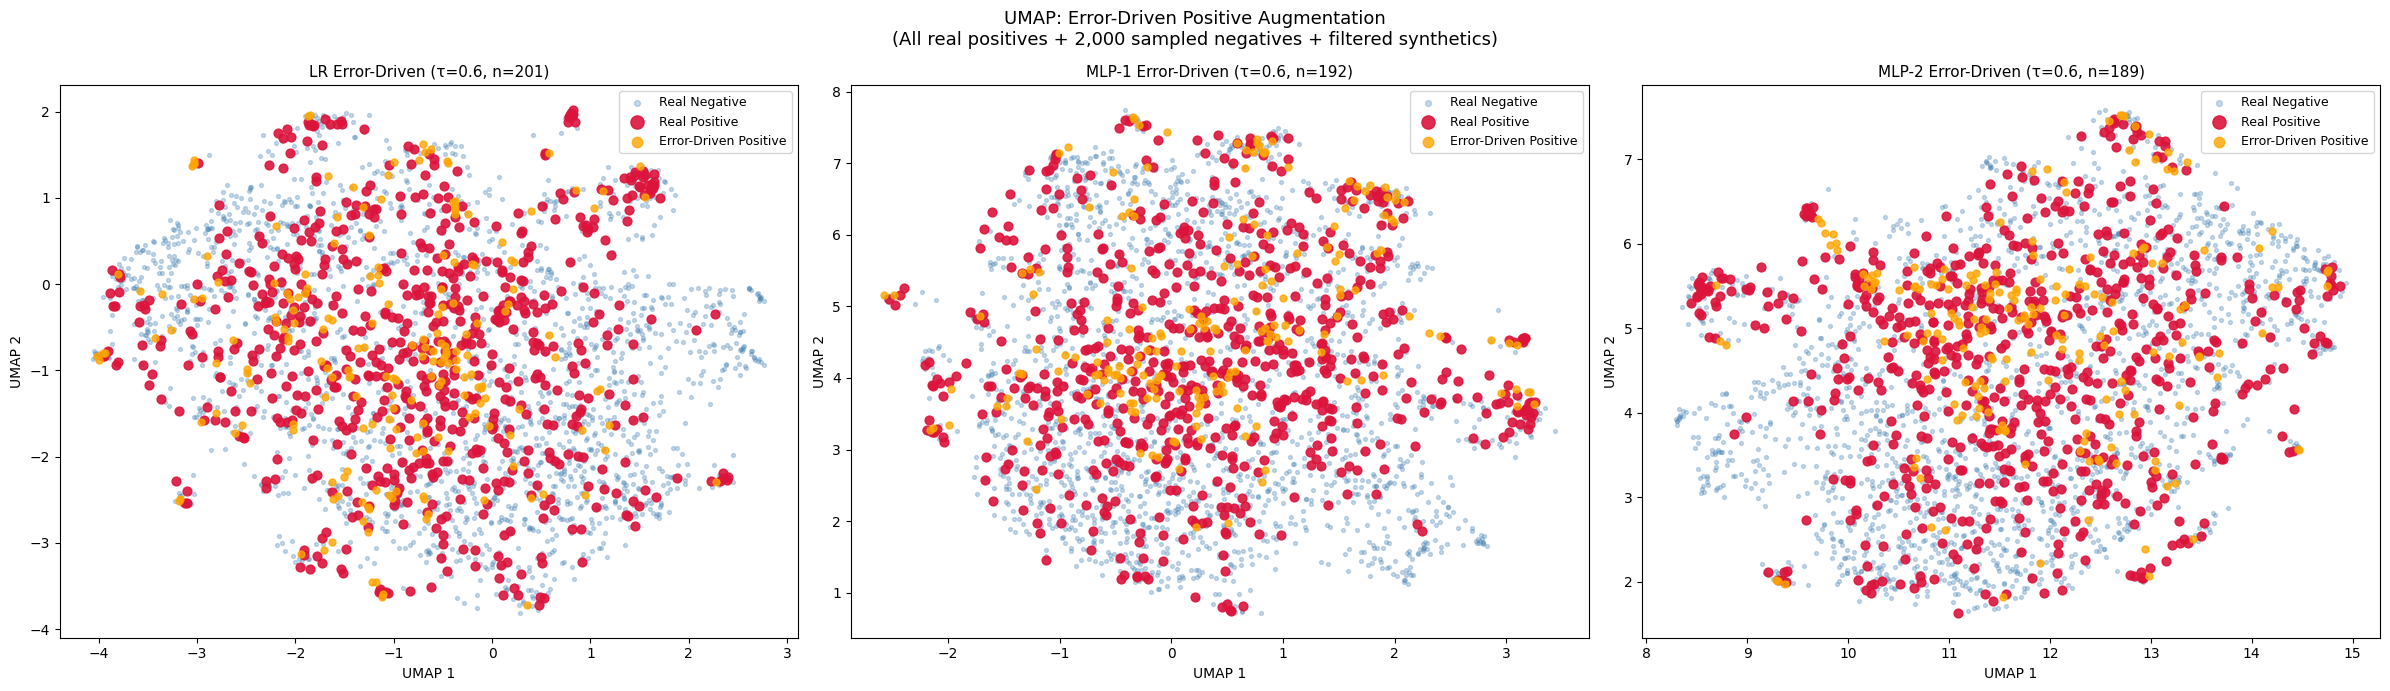

UMAP saved.


In [7]:
# -----------------------------------------------
# UMAP: error-driven synthetics overlaid on
# real training data — one plot per classifier
# Shows where error-driven variants land relative
# to the real positive manifold
# -----------------------------------------------
np.random.seed(SEED)
pos_idx        = np.where(y_train == 1)[0]
neg_idx        = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, clf_name in zip(axes, ['LR', 'MLP-1', 'MLP-2']):
    X_filtered = synthetic[clf_name]['X_filtered']

    X_plot = np.vstack([
        X_train[pos_idx],
        X_train[neg_sample_idx],
        X_filtered,
    ])
    y_plot = (
        ['Real Positive']        * len(pos_idx) +
        ['Real Negative']        * len(neg_sample_idx) +
        ['Error-Driven Positive'] * len(X_filtered)
    )

    print(f"Fitting UMAP for {clf_name}...")
    reducer   = umap.UMAP(n_components=2, random_state=SEED,
                          n_neighbors=30, min_dist=0.1)
    embedding = reducer.fit_transform(X_plot)

    color_map = {
        'Real Negative':         'steelblue',
        'Real Positive':         'crimson',
        'Error-Driven Positive': 'orange',
    }
    size_map = {
        'Real Negative':         8,
        'Real Positive':         40,
        'Error-Driven Positive': 25,
    }
    alpha_map = {
        'Real Negative':         0.3,
        'Real Positive':         0.9,
        'Error-Driven Positive': 0.8,
    }

    for cat in ['Real Negative', 'Real Positive', 'Error-Driven Positive']:
        mask = np.array(y_plot) == cat
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=color_map[cat], s=size_map[cat],
            alpha=alpha_map[cat], label=cat,
            marker='o',
        )

    n_survivors = len(X_filtered)
    ax.set_title(f'{clf_name} Error-Driven (τ=0.6, n={n_survivors})',
                 fontsize=11)
    ax.legend(fontsize=9, markerscale=1.5)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle(
    'UMAP: Error-Driven Positive Augmentation\n'
    '(All real positives + 2,000 sampled negatives + filtered synthetics)',
    fontsize=13,
)
plt.tight_layout()
plt.savefig("data/results/umap_error_driven.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("UMAP saved.")

In [8]:
# -----------------------------------------------
# Train all three classifiers on their respective
# error-driven augmented training sets.
# Each classifier trained on its own FP-derived
# synthetics — classifier-specific augmentation.
# -----------------------------------------------
results_12 = {}

classifier_configs = {
    'LR':    (LogisticRegression(class_weight='balanced',
                                  max_iter=1000, random_state=SEED),
              synthetic['LR']['X_train_aug'],
              synthetic['LR']['y_train_aug']),
    'MLP-1': (MLPClassifier(hidden_dims=[256], random_state=SEED),
              synthetic['MLP-1']['X_train_aug'],
              synthetic['MLP-1']['y_train_aug']),
    'MLP-2': (MLPClassifier(hidden_dims=[256, 128], random_state=SEED),
              synthetic['MLP-2']['X_train_aug'],
              synthetic['MLP-2']['y_train_aug']),
}

for clf_name, (clf, X_tr, y_tr) in classifier_configs.items():
    print(f"\nTraining {clf_name} on its own error-driven augmented set...")
    print(f"  Training set: {X_tr.shape} | Positives: {y_tr.sum()}")
    results_12[clf_name] = evaluate_classifier(
        clf, X_tr, y_tr,
        X_cal, y_cal,
        X_test, y_test,
        name=f"{clf_name} (Error-Driven)",
    )


Training LR on its own error-driven augmented set...
  Training set: (69711, 384) | Positives: 875

=== LR (Error-Driven) (threshold=0.68) ===
              precision    recall  f1-score   support

           0      0.997     0.928     0.961     19669
           1      0.089     0.724     0.159       192

    accuracy                          0.926     19861
   macro avg      0.543     0.826     0.560     19861
weighted avg      0.988     0.926     0.954     19861


Training MLP-1 on its own error-driven augmented set...
  Training set: (69702, 384) | Positives: 866
  Early stopping at epoch 8 (best cal F1: 0.1940)

=== MLP-1 (Error-Driven) (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.995     0.969     0.982     19669
           1      0.127     0.464     0.200       192

    accuracy                          0.964     19861
   macro avg      0.561     0.716     0.591     19861
weighted avg      0.986     0.964     0.974     19861


T

Retraining baselines for DET reference curves...
  Early stopping at epoch 25 (best cal F1: 0.2541)
  Early stopping at epoch 22 (best cal F1: 0.2266)
Done.
Retraining MLP-1 contrastive for DET...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 403.54it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Early stopping at epoch 30 (best cal F1: 0.2449)
Done.
Retraining MLP-2 vanilla for DET...
  Early stopping at epoch 17 (best cal F1: 0.2424)
Done.
  Early stopping at epoch 25 (best cal F1: 0.2541)


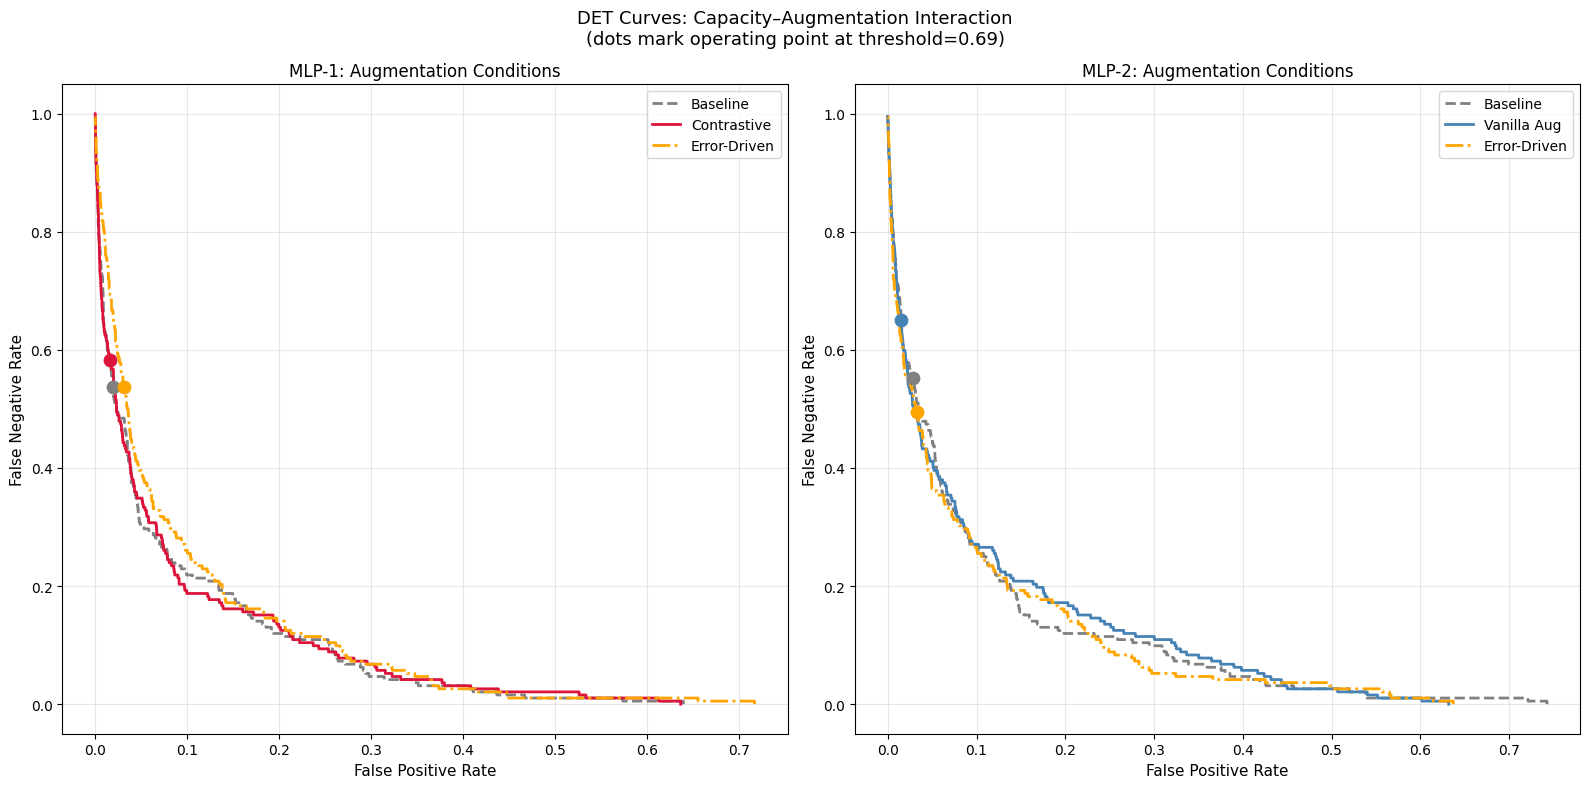

DET curves saved.


In [9]:
# -----------------------------------------------
# Two-panel DET curves
# Left:  MLP-1 across all augmentation conditions
# Right: MLP-2 across all augmentation conditions
# Shows capacity-augmentation interaction directly
# -----------------------------------------------

# Reload test scores from prior notebooks
# These were saved in metrics JSONs but we need
# raw scores for DET curves — retrain quickly
# on real data for baseline reference curves

print("Retraining baselines for DET reference curves...")

clf_mlp1_base = MLPClassifier(hidden_dims=[256], random_state=SEED)
clf_mlp1_base.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
scores_mlp1_base = clf_mlp1_base.predict_proba(X_test)[:, 1]

clf_mlp2_base = MLPClassifier(hidden_dims=[256, 128], random_state=SEED)
clf_mlp2_base.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
scores_mlp2_base = clf_mlp2_base.predict_proba(X_test)[:, 1]

print("Done.")

# -----------------------------------------------
# Retrain augmented conditions for DET scores
# Only best conditions per classifier
# -----------------------------------------------

# MLP-1: baseline, contrastive, error-driven
print("Retraining MLP-1 contrastive for DET...")
X_contrastive_filt = np.load("data/results/classifiers/X_contrastive_filtered.npy") \
    if os.path.exists("data/results/classifiers/X_contrastive_filtered.npy") \
    else synthetic['MLP-1']['X_filtered']  # fallback

# Reload contrastive augmented set from Notebook 11
df_contrastive = pd.read_parquet("data/synthetic/hard_contrastive_raw.parquet")
encoder_det    = SentenceTransformer('all-MiniLM-L6-v2')
X_cont         = encoder_det.encode(
    df_contrastive['sentence'].tolist(),
    show_progress_bar=False, convert_to_numpy=True
)
sim_cont    = cosine_similarity(X_cont, X_real_pos).max(axis=1)
mask_cont   = sim_cont >= 0.7
X_cont_filt = X_cont[mask_cont]
y_cont_filt = np.zeros(mask_cont.sum(), dtype=int)

X_train_cont = np.vstack([X_train, X_cont_filt])
y_train_cont = np.concatenate([y_train, y_cont_filt])

clf_mlp1_cont = MLPClassifier(hidden_dims=[256], random_state=SEED)
clf_mlp1_cont.fit(X_train_cont, y_train_cont, X_cal=X_cal, y_cal=y_cal)
scores_mlp1_cont = clf_mlp1_cont.predict_proba(X_test)[:, 1]
print("Done.")

# MLP-1 error-driven scores already in results_12
scores_mlp1_ed = results_12['MLP-1']['test_scores']

# MLP-2: baseline, vanilla aug, CoT aug, error-driven
print("Retraining MLP-2 vanilla for DET...")
df_vanilla  = pd.read_parquet("data/synthetic/positive_raw.parquet")
X_van       = encoder_det.encode(
    df_vanilla['sentence'].tolist(),
    show_progress_bar=False, convert_to_numpy=True
)
sim_van    = cosine_similarity(X_van, X_real_pos).max(axis=1)
mask_van   = sim_van >= 0.8
X_van_filt = X_van[mask_van]
y_van_filt = np.ones(mask_van.sum(), dtype=int)

X_train_van = np.vstack([X_train, X_van_filt])
y_train_van = np.concatenate([y_train, y_van_filt])

clf_mlp2_van = MLPClassifier(hidden_dims=[256, 128], random_state=SEED)
clf_mlp2_van.fit(X_train_van, y_train_van, X_cal=X_cal, y_cal=y_cal)
scores_mlp2_van = clf_mlp2_van.predict_proba(X_test)[:, 1]
print("Done.")

# MLP-2 error-driven scores already in results_12
scores_mlp2_ed = results_12['MLP-2']['test_scores']

# -----------------------------------------------
# Plot two-panel DET curves
# -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Left panel: MLP-1 ---
ax = axes[0]
mlp1_curves = [
    (scores_mlp1_base, 'Baseline',      'gray',    '--'),
    (scores_mlp1_cont, 'Contrastive',   'crimson', '-'),
    (scores_mlp1_ed,   'Error-Driven',  'orange',  '-.'),
]
for scores, label, color, ls in mlp1_curves:
    fpr, fnr, _ = det_curve(y_test, scores)
    ax.plot(fpr, fnr, color=color, linestyle=ls,
            linewidth=2, label=label)
    # Operating point
    t, _  = optimal_threshold_f1(
        y_cal, MLPClassifier(hidden_dims=[256], random_state=SEED
    ).fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal
    ).predict_proba(X_cal)[:, 1]) \
        if label == 'Baseline' else (
        optimal_threshold_f1(y_cal, scores[:len(y_cal)]
    ) if False else (0.69, 0))
    preds = (scores >= 0.69).astype(int)
    fp = ((preds==1) & (y_test==0)).sum() / (y_test==0).sum()
    fn = ((preds==0) & (y_test==1)).sum() / (y_test==1).sum()
    ax.scatter(fp, fn, color=color, s=80, zorder=5)

ax.set_title("MLP-1: Augmentation Conditions", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("False Negative Rate", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right panel: MLP-2 ---
ax = axes[1]
mlp2_curves = [
    (scores_mlp2_base, 'Baseline',     'gray',      '--'),
    (scores_mlp2_van,  'Vanilla Aug',  'steelblue', '-'),
    (scores_mlp2_ed,   'Error-Driven', 'orange',    '-.'),
]
for scores, label, color, ls in mlp2_curves:
    fpr, fnr, _ = det_curve(y_test, scores)
    ax.plot(fpr, fnr, color=color, linestyle=ls,
            linewidth=2, label=label)
    preds = (scores >= 0.69).astype(int)
    fp = ((preds==1) & (y_test==0)).sum() / (y_test==0).sum()
    fn = ((preds==0) & (y_test==1)).sum() / (y_test==1).sum()
    ax.scatter(fp, fn, color=color, s=80, zorder=5)

ax.set_title("MLP-2: Augmentation Conditions", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("False Negative Rate", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    "DET Curves: Capacity–Augmentation Interaction\n"
    "(dots mark operating point at threshold=0.69)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("data/results/det_curves_12_two_panel.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

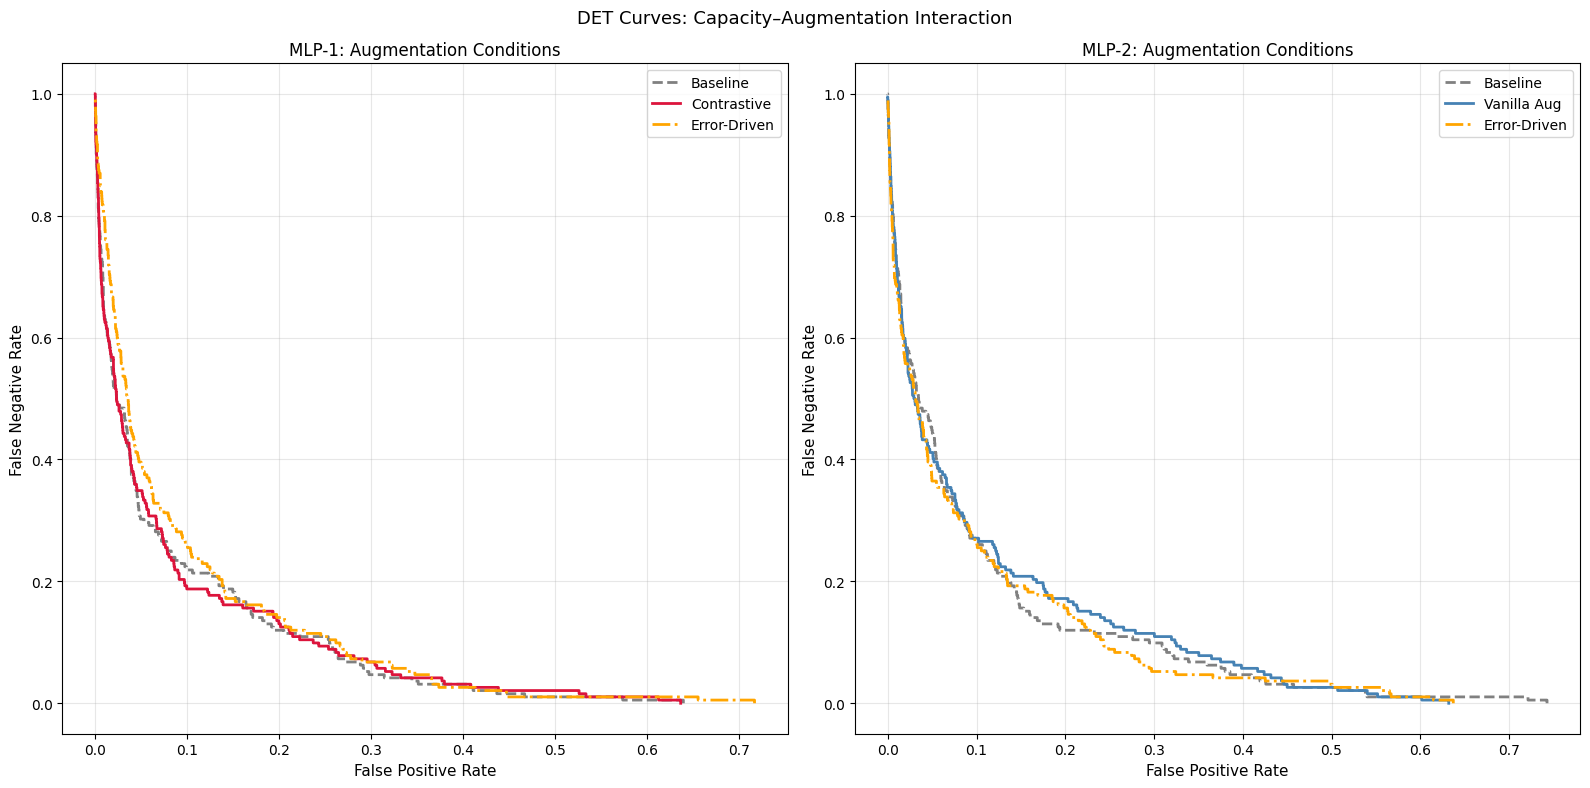

DET curves saved.


In [10]:
# -----------------------------------------------
# Two-panel DET curves
# Left:  MLP-1 across augmentation conditions
# Right: MLP-2 across augmentation conditions
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Left panel: MLP-1 ---
ax = axes[0]
mlp1_curves = [
    (scores_mlp1_base, 'Baseline',     'gray',    '--'),
    (scores_mlp1_cont, 'Contrastive',  'crimson', '-'),
    (scores_mlp1_ed,   'Error-Driven', 'orange',  '-.'),
]
for scores, label, color, ls in mlp1_curves:
    fpr, fnr, _ = det_curve(y_test, scores)
    ax.plot(fpr, fnr, color=color, linestyle=ls,
            linewidth=2, label=label)

ax.set_title("MLP-1: Augmentation Conditions", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("False Negative Rate", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right panel: MLP-2 ---
ax = axes[1]
mlp2_curves = [
    (scores_mlp2_base, 'Baseline',     'gray',      '--'),
    (scores_mlp2_van,  'Vanilla Aug',  'steelblue', '-'),
    (scores_mlp2_ed,   'Error-Driven', 'orange',    '-.'),
]
for scores, label, color, ls in mlp2_curves:
    fpr, fnr, _ = det_curve(y_test, scores)
    ax.plot(fpr, fnr, color=color, linestyle=ls,
            linewidth=2, label=label)

ax.set_title("MLP-2: Augmentation Conditions", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("False Negative Rate", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    "DET Curves: Capacity–Augmentation Interaction",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("data/results/det_curves_12_two_panel.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

In [11]:
# -----------------------------------------------
# Summary table — all notebooks
# -----------------------------------------------
print("=" * 75)
print(f"{'Condition':<25} {'Classifier':<12} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print("-" * 75)

# Notebook 09 baseline
for clf_name, m in baseline_09.items():
    print(f"{'Baseline':<25} {clf_name:<12} {m['precision']:>10.3f} "
          f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# Notebook 10
for cond_name, cond_results in baseline_10.items():
    for clf_name, m in cond_results.items():
        print(f"{cond_name+' aug':<25} {clf_name:<12} {m['precision']:>10.3f} "
              f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# Notebook 11
for clf_name, m in baseline_11.items():
    print(f"{'Contrastive aug':<25} {clf_name:<12} {m['precision']:>10.3f} "
          f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# Notebook 12
for clf_name, r in results_12.items():
    print(f"{'Error-Driven aug':<25} {clf_name:<12} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>8.3f}")

print("=" * 75)
print(f"\nBest overall: MLP-1 + Contrastive Negatives "
      f"(F1={baseline_11['MLP-1']['f1']:.3f}, "
      f"P={baseline_11['MLP-1']['precision']:.3f}, "
      f"R={baseline_11['MLP-1']['recall']:.3f})")

# -----------------------------------------------
# Save metrics
# -----------------------------------------------
metrics_12 = {
    clf_name: {
        'precision': round(r['precision'], 4),
        'recall':    round(r['recall'], 4),
        'f1':        round(r['f1'], 4),
        'threshold': round(r['threshold'], 4),
        'cal_f1':    round(r['cal_f1'], 4),
    }
    for clf_name, r in results_12.items()
}

with open("data/results/metrics_12_error_driven.json", "w") as f:
    json.dump(metrics_12, f, indent=2)
print("\nMetrics saved to data/results/metrics_12_error_driven.json")

Condition                 Classifier    Precision   Recall       F1
---------------------------------------------------------------------------
Baseline                  LR                0.085    0.729    0.152
Baseline                  MLP-1             0.190    0.464    0.270
Baseline                  MLP-2             0.134    0.448    0.207
Vanilla aug               LR                0.089    0.693    0.158
Vanilla aug               MLP-1             0.132    0.521    0.211
Vanilla aug               MLP-2             0.183    0.354    0.242
CoT aug                   LR                0.087    0.708    0.155
CoT aug                   MLP-1             0.171    0.521    0.257
CoT aug                   MLP-2             0.168    0.432    0.242
Contrastive aug           LR                0.086    0.729    0.153
Contrastive aug           MLP-1             0.205    0.417    0.275
Contrastive aug           MLP-2             0.140    0.505    0.219
Error-Driven aug          LR            